# Umfassende Evaluation auf TextComplexityDE (Naderi et al., 2019)
#### Empirischer Benchmark aller Regressoren, Klassifikatoren und traditionellen Lesbarkeitsmetriken auf 1.000 deutschen Wikipedia-Sätzen mit menschlichen Urteilen

---

## 1. Überblick & Fragestellung

Der **TextComplexityDE-Benchmark** (Naderi et al., 2019) umfasst 1.000 deutsche Wikipedia-Sätze, die von Deutschlernenden auf einer 7-Punkte-Likert-Skala hinsichtlich mehrerer Dimensionen bewertet wurden:
- **MOS_Complexity:** Gesamtsprachliche Komplexität (1 = sehr einfach, 7 = sehr komplex)
- **MOS_Understandability:** Verständlichkeit
- **MOS_Lexical_difficulty:** Lexikalische Schwierigkeit (Wortschatz)

In diesem Notebook untersuchen wir:
1. **Regressoren:** Wie gut korrelieren die **MixUp-Regressoren (256, 512, 1024 Tokens)** mit menschlicher Einfachheit?
2. **Klassifikatoren:** Liefert die kontinuierliche Wahrscheinlichkeit P(LS) des **Satz-Klassifikators** bzw. der Artikel-Klassifikatoren eine valide Komplexitätsmetrik auf externen Sätzen?
3. **Vergleich mit traditionellen Formeln:** Übertreffen die neuronalen Modelle klassische Maße wie Flesch Reading Ease, Wiener Sachtextformel und LIX?


In [1]:
import os
import sys
import json
import urllib.request
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, "data")) and os.path.exists(os.path.join(p, "results")):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser("~/Documents/Master Thesis"))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Arbeitsverzeichnis:", os.getcwd())

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.dpi": 150
})


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 1. TextComplexityDE Benchmark-Daten laden

Einlesen der vorberechneten Modellvorhersagen auf den 1.000 Wikipedia-Sätzen.

In [2]:
# 1. Benchmark-Daten und Modell-Vorhersagen laden
csv_path_all = "results/evaluation/textcomplexityde_all_models_eval.csv"
csv_path_fallback = "results/evaluation/textcomplexityde_eval.csv"

if os.path.exists(csv_path_all):
    df_tc = pd.read_csv(csv_path_all)
    print(f"-> Detail-Vorhersagen geladen ({len(df_tc)} Sätze): {csv_path_all}")
elif os.path.exists(csv_path_fallback):
    df_tc = pd.read_csv(csv_path_fallback)
    print(f"-> Fallback-Vorhersagen geladen: {csv_path_fallback}")
else:
    raise FileNotFoundError("Keine TextComplexityDE Evaluations-CSV gefunden!")

y_simp = df_tc["Human_Simplicity"].values if "Human_Simplicity" in df_tc.columns else 1.0 - (df_tc["MOS_Complexity"] - 1.0)/6.0
y_comp = df_tc["MOS_Complexity"].values
y_und = df_tc["MOS_Understandability"].values if "MOS_Understandability" in df_tc.columns else y_simp
y_lex = df_tc["MOS_Lexical_difficulty"].values if "MOS_Lexical_difficulty" in df_tc.columns else y_comp


-> Detail-Vorhersagen geladen (1000 Sätze): results/evaluation/textcomplexityde_all_models_eval.csv


## 2. Statistische Korrelationen & Performanz-Metriken

In [3]:
# Master-Tabelle für TextComplexityDE berechnen
summary_json_path = "results/evaluation/textcomplexityde_summary.json"

if os.path.exists(summary_json_path):
    with open(summary_json_path, "r", encoding="utf-8") as f:
        summary_data = json.load(f)
    df_summary_tc = pd.DataFrame(summary_data)
else:
    # Falls JSON nicht vorhanden, berechne aus Spalten der CSV
    records = []
    for col in df_tc.columns:
        if col.startswith("Pred_"):
            m_name = col.replace("Pred_", "").replace("_", " ")
            sc = df_tc[col].values
            r_s, _ = pearsonr(sc, y_simp)
            rho_s, _ = spearmanr(sc, y_simp)
            tau_s, _ = kendalltau(sc, y_simp)
            r_u, _ = pearsonr(sc, y_und)
            r_l, _ = pearsonr(sc, -y_lex)
            records.append({
                "Modell": m_name,
                "Pearson r (Simplicity)": r_s,
                "Spearman ρ (Rang)": rho_s,
                "Kendall τ": tau_s,
                "Pearson r (Verständlichkeit)": r_u,
                "Pearson r (Lexikalisch)": r_l
            })
    df_summary_tc = pd.DataFrame(records)

cols_disp = ["Modell", "Kategorie", "Pearson r (Simplicity)", "Spearman ρ (Rang)", "Pearson r (Verständlichkeit)", "Pearson r (Lexikalisch)", "MAE (normiert)"]
cols_final = [c for c in cols_disp if c in df_summary_tc.columns]

display(df_summary_tc[cols_final].sort_values(by="Pearson r (Simplicity)", ascending=False).reset_index(drop=True))


,Modell,Kategorie,Pearson r (Simplicity),Spearman ρ (Rang),Pearson r (Verständlichkeit),Pearson r (Lexikalisch),MAE (normiert)
0,LIX Lesbarkeitsindex,Baseline,0.657281,0.641251,-0.567389,0.606786,0.177194
1,BiLSTM MixUp Regressor (256),Regressor (256),0.620151,0.579301,-0.553726,0.607460,0.198385
2,BiLSTM MixUp Regressor (512),Regressor (512),0.610103,0.589867,-0.556161,0.623226,0.329410
3,BiLSTM MixUp Regressor (1024),Regressor (1024),0.594965,0.600719,-0.553586,0.624005,0.473256
4,Wiener Sachtextformel,Baseline,0.539878,0.518735,-0.465124,0.508144,0.164194
5,BiLSTM Artikel-Klassifikator (1024),Klassifikator (1024),0.532173,0.406655,-0.495167,0.562460,0.506999
6,BiLSTM Satz-Klassifikator,Klassifikator (Satz),0.522413,0.635102,-0.497227,0.568615,0.523639
7,Flesch Reading Ease,Baseline,0.455670,0.455866,-0.382110,0.426854,0.174300


## 3. Visualisierungen: Umfassende Multi-Model-Vergleiche

Die folgenden Plots stellen alle 11 Modelle (Regressoren, Klassifikatoren und Lesbarkeits-Baselines) gegenüber:
1. **Korrelations-Barchart:** Direkter Vergleich von Pearson $ und Spearman $\rho$.
2. **Streudiagramm-Grid (11 Subplots):** Lineare Regression aller Modelle gegen die menschliche Simplicity.
3. **Monotonie-Boxplot-Grid (11 Subplots):** Verteilung der Modell-Scores über die 5 menschlichen Komplexitätsstufen.


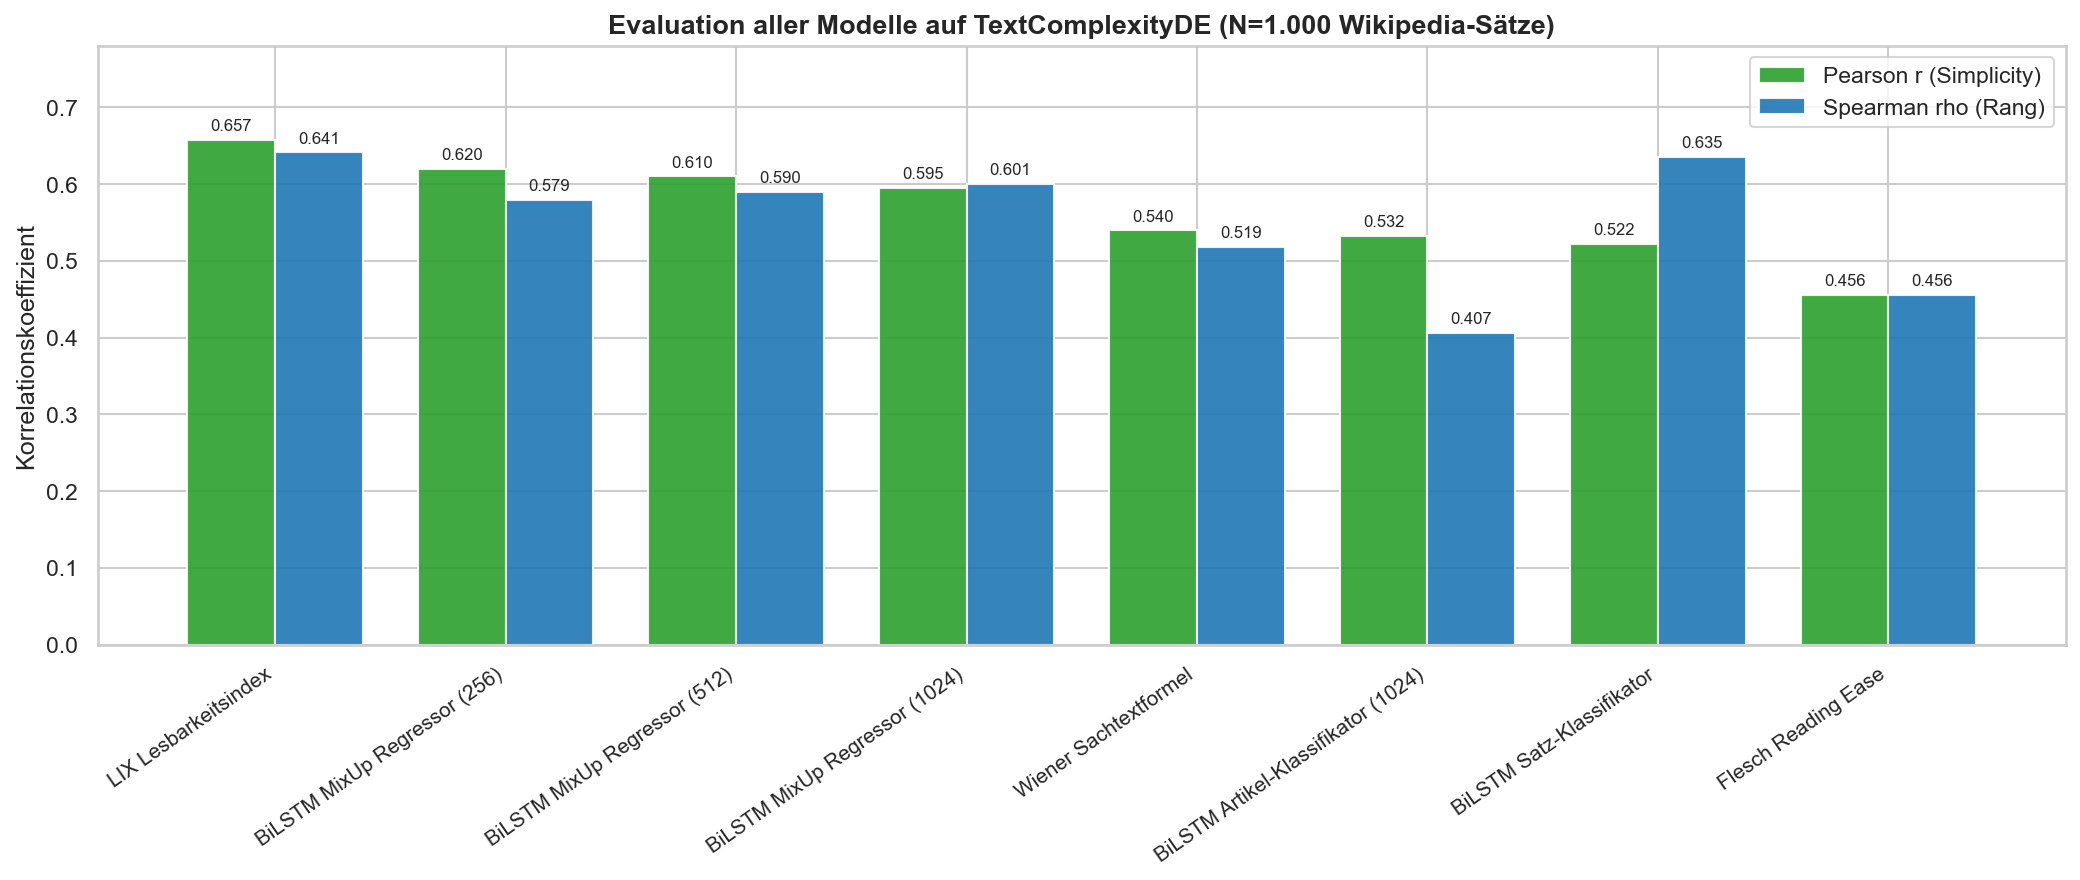

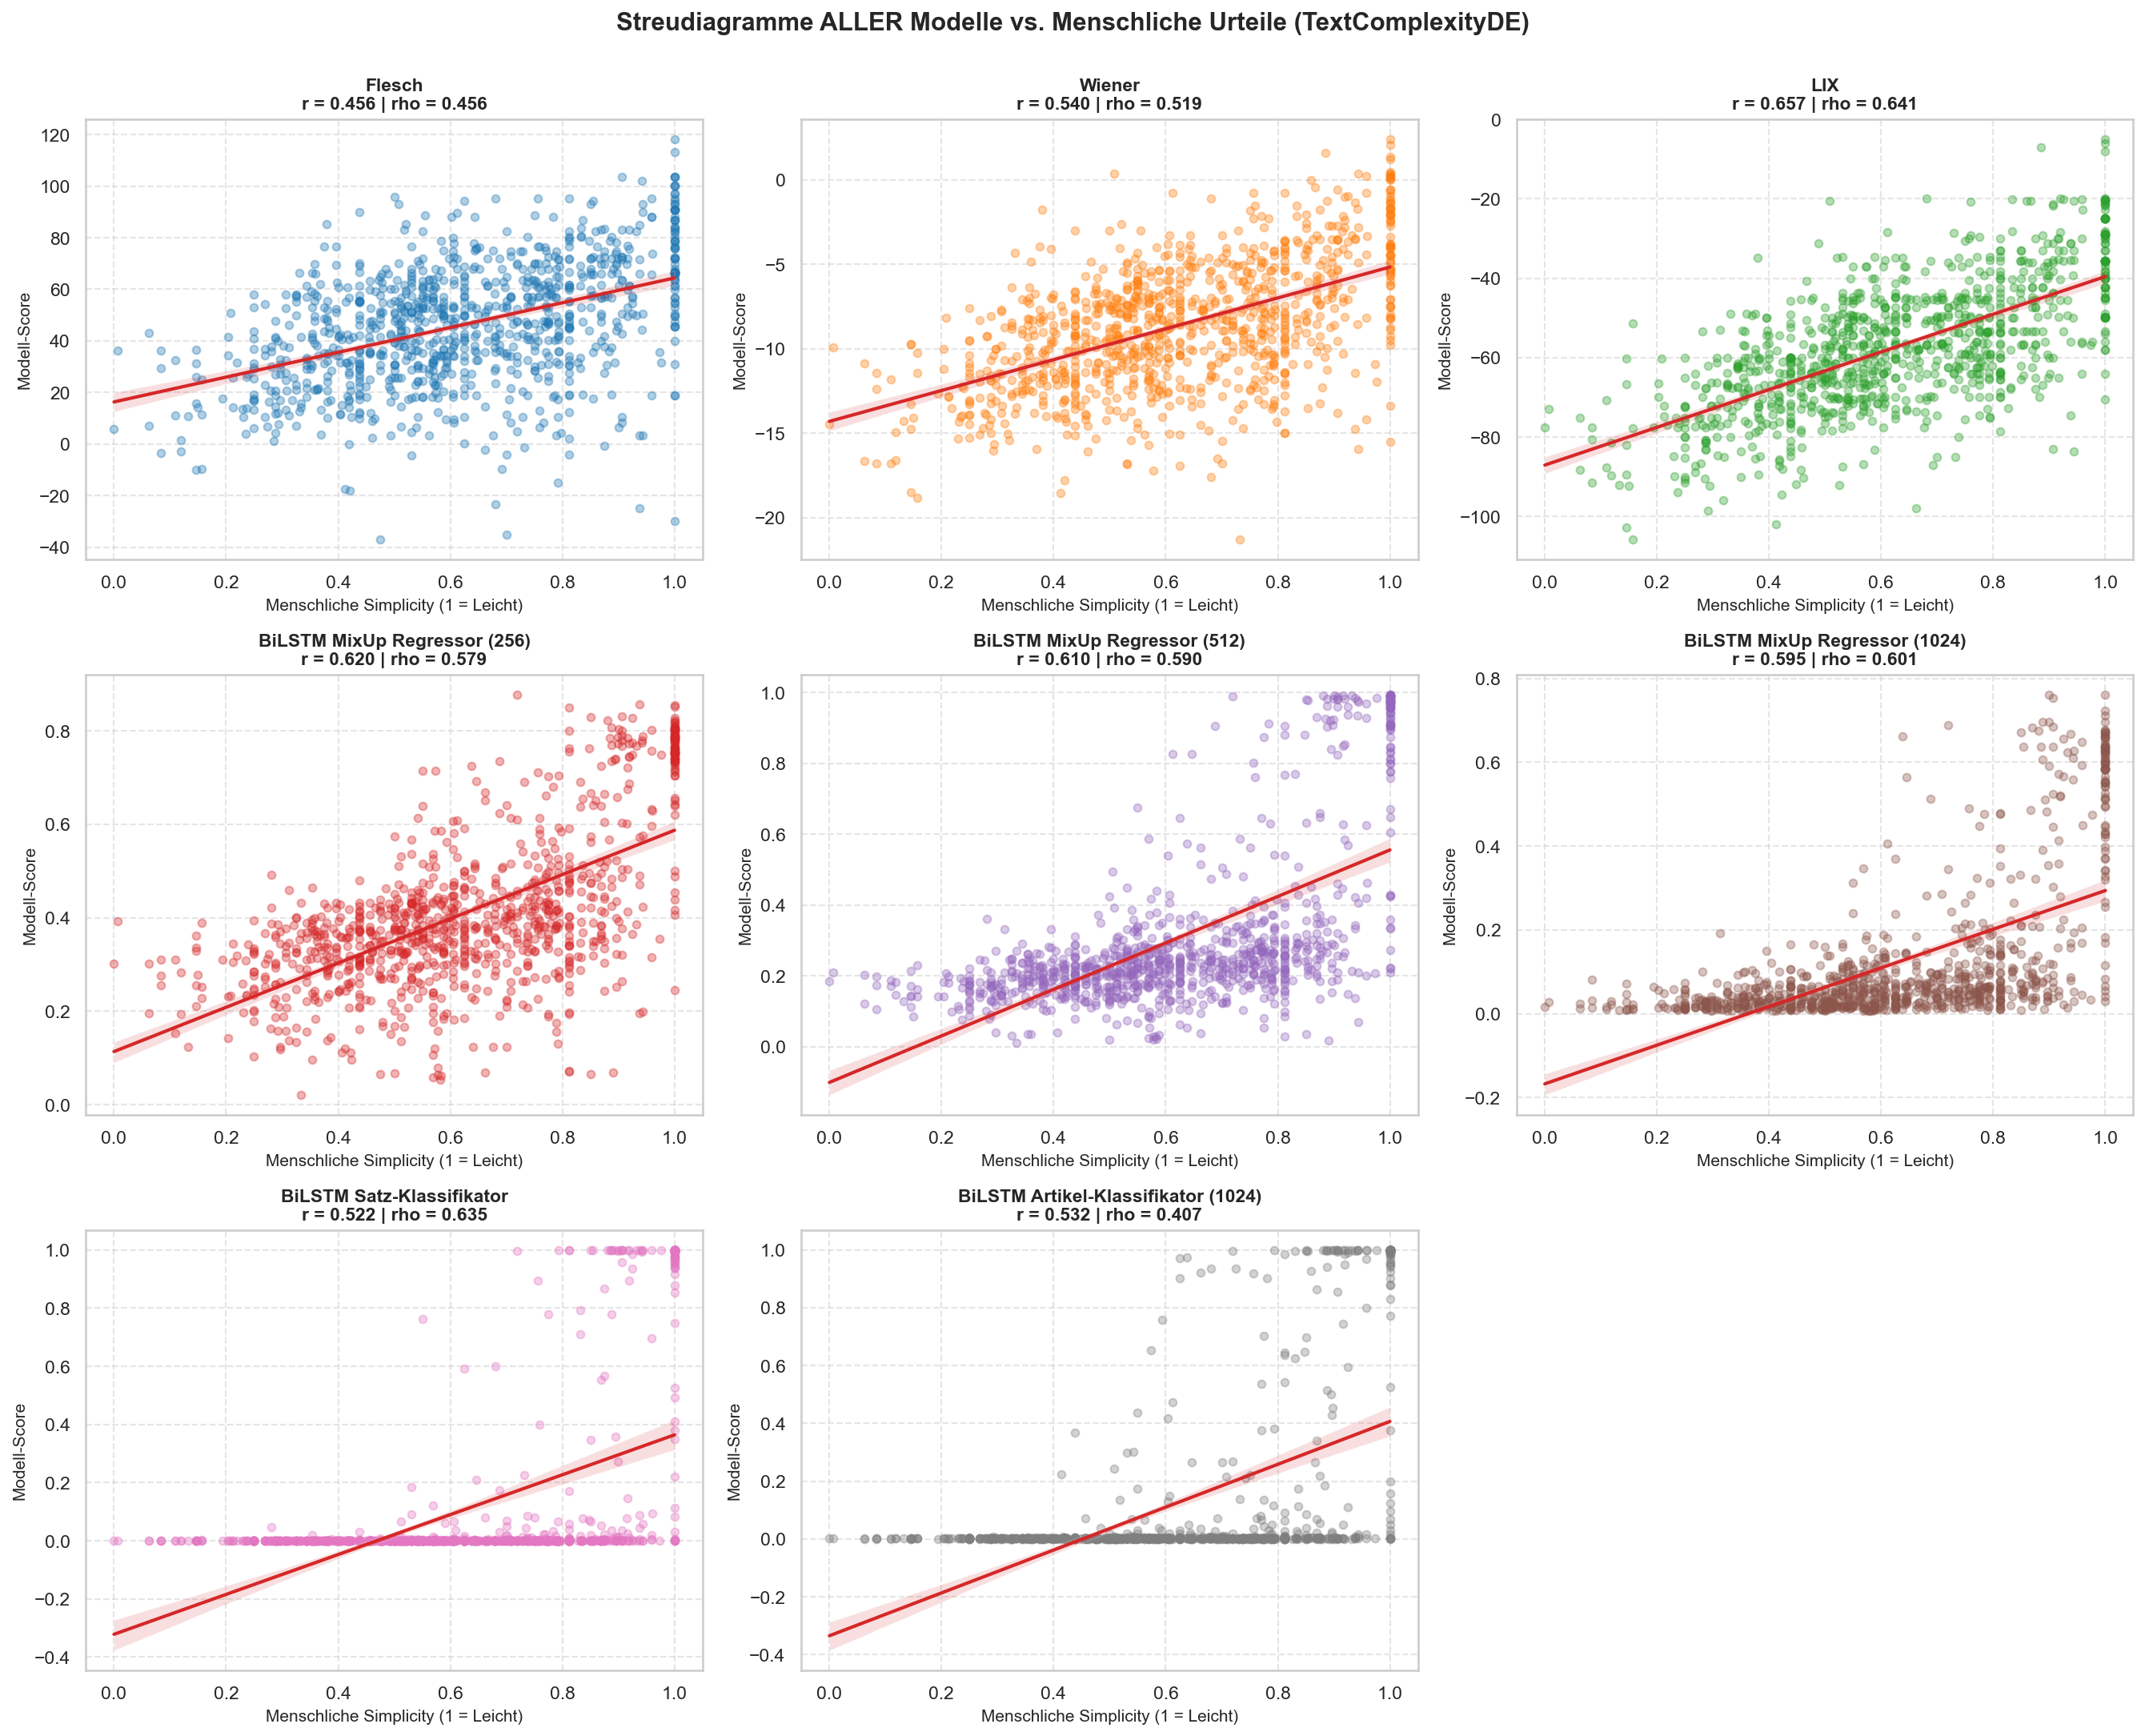

In [4]:
# ==============================================================================
# 1. BARCHART: KORRELATIONSKOEFFIZIENTEN ALLER MODELLE
# ==============================================================================
plt.figure(figsize=(14, 6))
df_plot = df_summary_tc.sort_values(by="Pearson r (Simplicity)", ascending=False)

x = np.arange(len(df_plot))
width = 0.38

plt.bar(x - width/2, df_plot["Pearson r (Simplicity)"], width, label="Pearson r (Simplicity)", color="#2ca02c", alpha=0.9)
plt.bar(x + width/2, df_plot["Spearman ρ (Rang)"], width, label="Spearman rho (Rang)", color="#1f77b4", alpha=0.9)

plt.xticks(x, df_plot["Modell"], rotation=35, ha="right", fontweight="medium", fontsize=10)
plt.ylabel("Korrelationskoeffizient", fontsize=12)
plt.title("Evaluation aller Modelle auf TextComplexityDE (N=1.000 Wikipedia-Sätze)", fontsize=13, fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.ylim(0, 0.78)
for i in range(len(df_plot)):
    plt.text(i - width/2, df_plot["Pearson r (Simplicity)"].iloc[i] + 0.012, f"{df_plot['Pearson r (Simplicity)'].iloc[i]:.3f}", ha="center", fontsize=8)
    plt.text(i + width/2, df_plot["Spearman ρ (Rang)"].iloc[i] + 0.012, f"{df_plot['Spearman ρ (Rang)'].iloc[i]:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. STREUDIAGRAMM-GRID FÜR ALLE 11 MODELLE
# ==============================================================================
pred_cols = [c for c in df_tc.columns if c.startswith("Pred_")]
if pred_cols:
    n_models = len(pred_cols)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.8 * n_rows))
    axes = axes.flatten()
    colors = sns.color_palette("tab10", n_models)
    
    for i, col in enumerate(pred_cols):
        m_label = col.replace("Pred_", "").replace("_", " ")
        r_val, _ = pearsonr(df_tc[col], y_simp)
        rho_val, _ = spearmanr(df_tc[col], y_simp)
        
        sns.regplot(
            x=y_simp, y=df_tc[col], ax=axes[i],
            color=colors[i % len(colors)],
            scatter_kws={'alpha': 0.35, 's': 22},
            line_kws={'color': '#d62728', 'lw': 2.0}
        )
        axes[i].set_title(f"{m_label}\nr = {r_val:.3f} | rho = {rho_val:.3f}", fontsize=11, fontweight="bold")
        axes[i].set_xlabel("Menschliche Simplicity (1 = Leicht)", fontsize=10)
        axes[i].set_ylabel("Modell-Score", fontsize=10)
        axes[i].grid(True, linestyle="--", alpha=0.5)
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle("Streudiagramme ALLER Modelle vs. Menschliche Urteile (TextComplexityDE)", fontsize=15, fontweight="bold", y=1.002)
    plt.tight_layout()
    os.makedirs("results/plots/experiments/textcomplexityde", exist_ok=True)
    plt.savefig("results/plots/experiments/textcomplexityde/textcomplexityde_scatter_all_models_grid.png", dpi=300, bbox_inches="tight")
    plt.show()


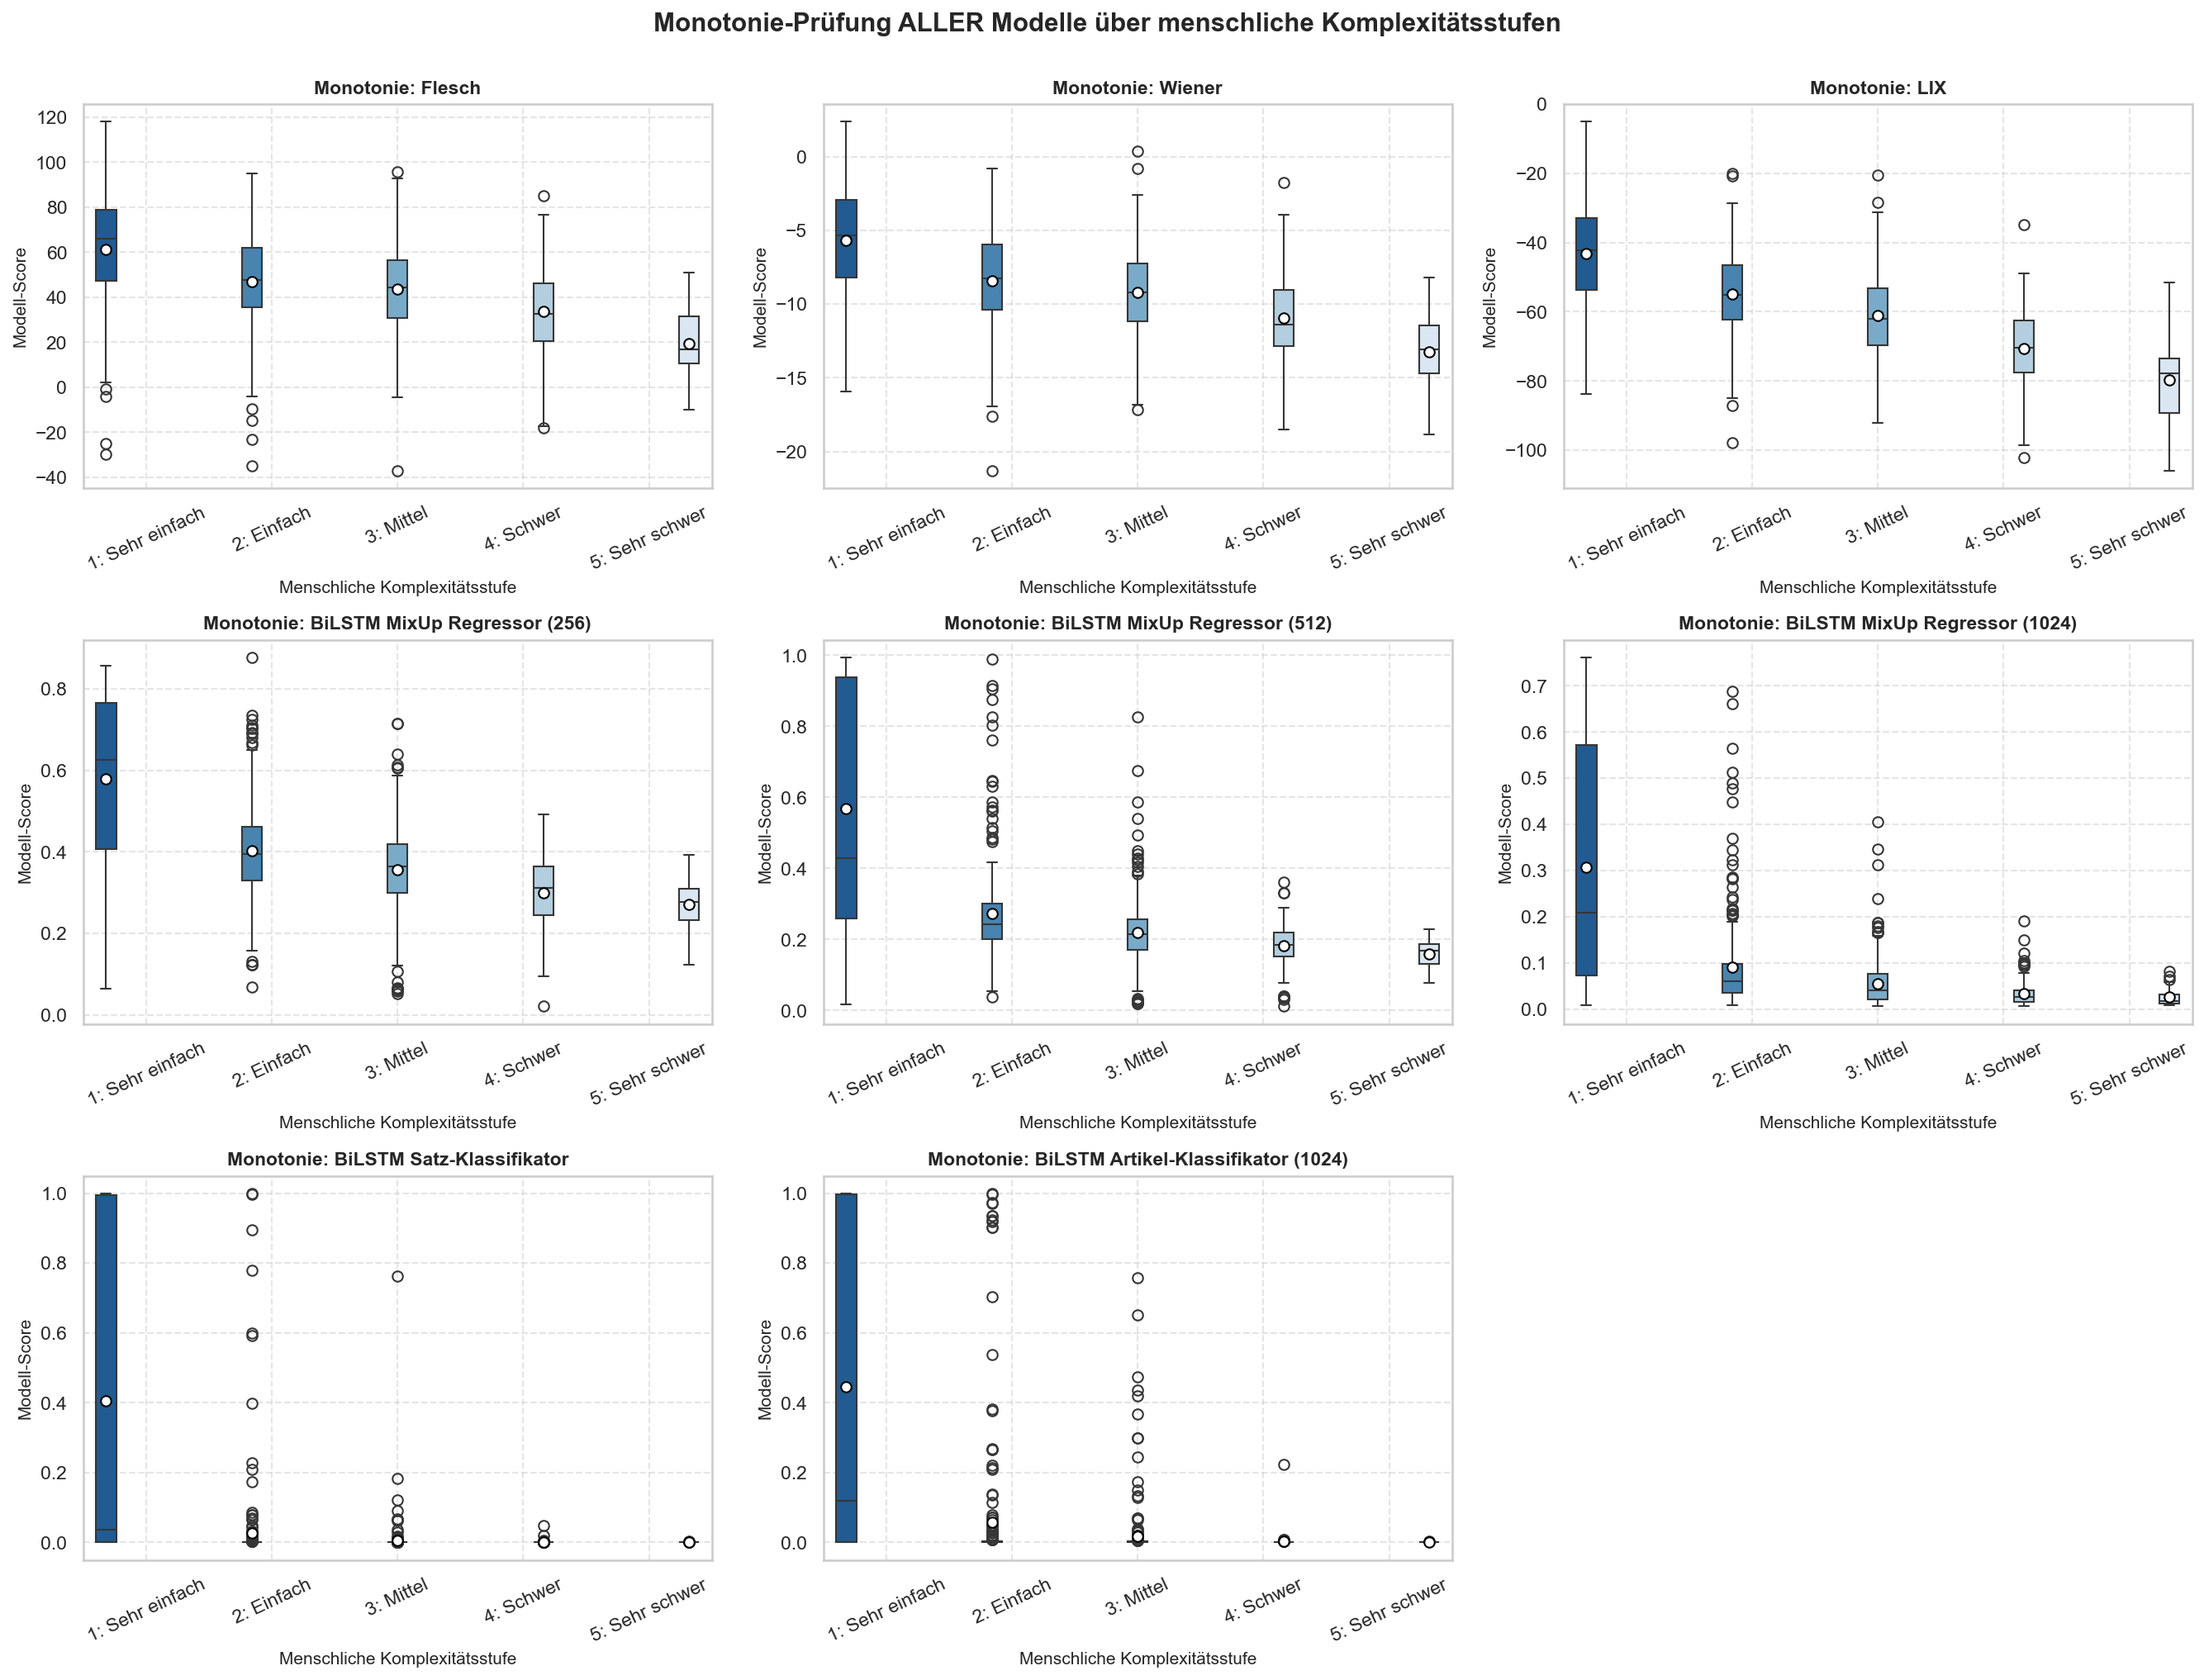

In [5]:
# ==============================================================================
# 3. MONOTONIE-BOXPLOT-GRID FÜR ALLE 11 MODELLE
# ==============================================================================
pred_cols = [c for c in df_tc.columns if c.startswith("Pred_")]
if pred_cols:
    bins = [1.0, 2.0, 3.0, 4.0, 5.0, 7.0]
    labels = ["1: Sehr einfach", "2: Einfach", "3: Mittel", "4: Schwer", "5: Sehr schwer"]
    df_tc["Complexity_Category"] = pd.cut(df_tc["MOS_Complexity"], bins=bins, labels=labels, include_lowest=True)
    
    n_models = len(pred_cols)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(pred_cols):
        m_label = col.replace("Pred_", "").replace("_", " ")
        sns.boxplot(
            data=df_tc, x="Complexity_Category", y=col, ax=axes[i],
            palette="Blues_r", hue="Complexity_Category", legend=False, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"}
        )
        axes[i].set_title(f"Monotonie: {m_label}", fontsize=11, fontweight="bold")
        axes[i].set_xlabel("Menschliche Komplexitätsstufe", fontsize=10)
        axes[i].set_ylabel("Modell-Score", fontsize=10)
        axes[i].tick_params(axis="x", rotation=25)
        axes[i].grid(True, linestyle="--", alpha=0.5)
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle("Monotonie-Prüfung ALLER Modelle über menschliche Komplexitätsstufen", fontsize=15, fontweight="bold", y=1.002)
    plt.tight_layout()
    plt.savefig("results/plots/experiments/textcomplexityde/textcomplexityde_boxplots_all_models_grid.png", dpi=300, bbox_inches="tight")
    plt.show()


## 4. Detail- & Ausreißeranalyse

In [6]:
# Detail- und Ausreißeranalyse für das beste Regressionsmodell
target_col = "Pred_BiLSTM_MixUp_Regressor_(1024)" if "Pred_BiLSTM_MixUp_Regressor_(1024)" in df_tc.columns else "pred_simplicity"

if target_col in df_tc.columns:
    df_tc["Simplicity_Diff"] = df_tc["Human_Simplicity"] - df_tc[target_col]
    
    print(f"=== Top 5 Sätze: Mensch urteilt EINFACH, Modell ({target_col}) urteilt SCHWER ===")
    top_under = df_tc.sort_values(by="Simplicity_Diff", ascending=False).head(5)
    for _, r in top_under.iterrows():
        print(f"• Text: {r['Sentence']}")
        print(f"  MOS Komplexität: {r['MOS_Complexity']:.2f} | Modell Score: {r[target_col]:.4f}")
        print()
        
    print(f"=== Top 5 Sätze: Mensch urteilt SCHWER, Modell ({target_col}) urteilt EINFACH ===")
    top_over = df_tc.sort_values(by="Simplicity_Diff", ascending=True).head(5)
    for _, r in top_over.iterrows():
        print(f"• Text: {r['Sentence']}")
        print(f"  MOS Komplexität: {r['MOS_Complexity']:.2f} | Modell Score: {r[target_col]:.4f}")
        print()


=== Top 5 Sätze: Mensch urteilt EINFACH, Modell (Pred_BiLSTM_MixUp_Regressor_(1024)) urteilt SCHWER ===
• Text: Dort heiratete er 1876 Pauline Koch und lebte in der Bahnhofstraße B135, wo Albert Einstein am 14 März 1879 zur Welt kam.
  MOS Komplexität: 1.00 | Modell Score: 0.0298

• Text: Martin Luther King Jr (* 15 Januar 1929 in Atlanta als Michael King Jr;  4 April 1968 in Memphis) war ein US-amerikanischer Baptistenpastor und Bürgerrechtler.
  MOS Komplexität: 1.00 | Modell Score: 0.0406

• Text: Der Direktor des Nobel-Institutes stellt den Sekretär des Komitees dar.
  MOS Komplexität: 1.00 | Modell Score: 0.0551

• Text: Präsident des Europäischen Parlaments ist seit dem 17 Januar 2017 Antonio Tajani (Europäische Volkspartei).
  MOS Komplexität: 1.14 | Modell Score: 0.0330

• Text: Unser Wohnhaus ist in der Nähe der Ravensburger Altstadt.
  MOS Komplexität: 1.00 | Modell Score: 0.0652

=== Top 5 Sätze: Mensch urteilt SCHWER, Modell (Pred_BiLSTM_MixUp_Regressor_(1024)) urteilt EIN